### Telco Customer Churn EDA
Customer Churn occurs when customers or subscribers stop doing business with a company or service. A company that has a high churn rate is losing a significant amount of revenue, as acquiring new customers often costs more than retaining existing ones.

### 1.Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import(
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    )
import shap
import joblib
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

### 2. Load Dataset


In [2]:
df = pd.read_csv(r"C:\Users\Brandon\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3. Initial Data Inspection

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 4.Data Cleaning

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df.dropna(subset=['TotalCharges'])

print("Shape after cleaning:", df.shape)

Shape after cleaning: (7032, 21)


### 5. Exploratory Data Analysis(EDA)

### 5.1 Churn Distribution

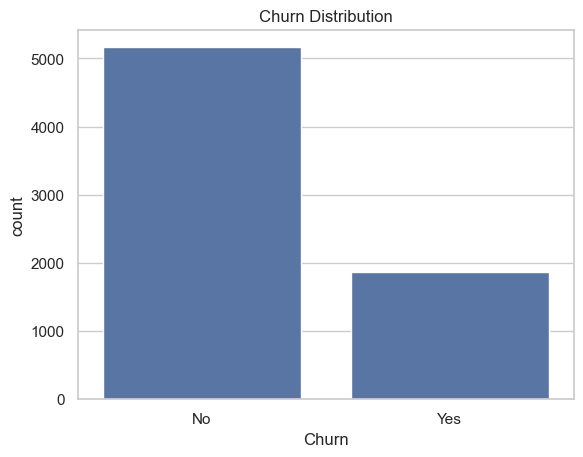

In [7]:
sns.countplot(x=df['Churn'])
plt.title("Churn Distribution")
plt.show()

### 5.2 Tenure vs Chrun

### Tenure 
how long a customer has been with the company

In the Telco Customer Churn dataset:

tenure is the number of months a customer has stayed with the company

So:

tenure = 1 → customer joined last month

tenure = 12 → customer has been with the company 1 year

tenure = 60 → customer has been with the company 5 years

### Churn
  when a customer stops using a company’s product or service

In simple terms:

A churned customer has left the company.

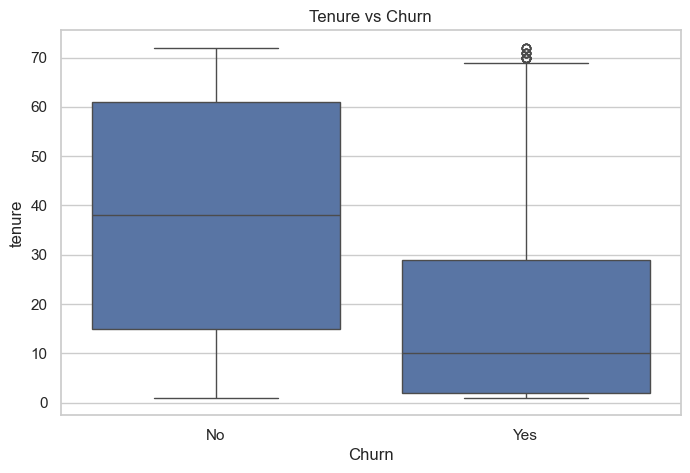

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert tenure to numeric (safe)
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')

# Drop missing values
df = df.dropna(subset=['Churn', 'tenure'])

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title("Tenure vs Churn")
plt.show()


### 5.3 Monthly Charges vs Churn


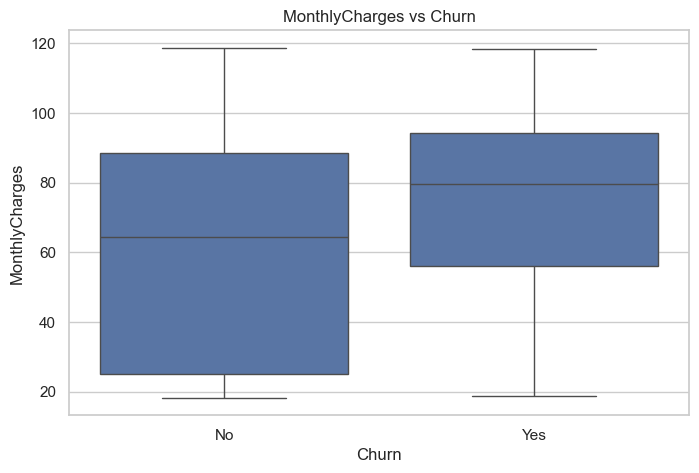

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Churn'], y=df['MonthlyCharges'])
plt.title("MonthlyCharges vs Churn")
plt.show()

### 5.4 Contract Vs Churn

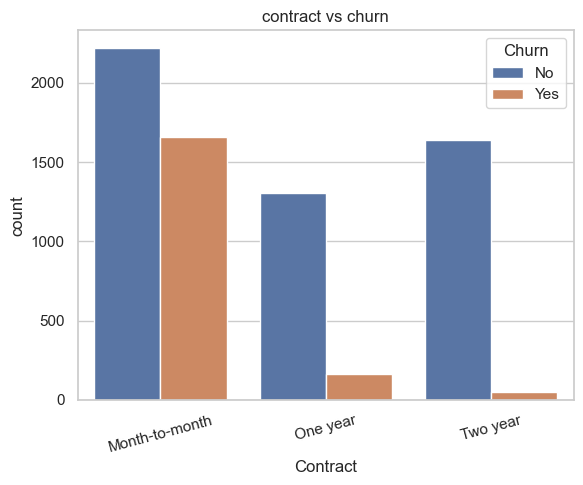

In [10]:
sns.countplot(x=df['Contract'], hue=df['Churn'])
plt.title("contract vs churn")
plt.xticks(rotation=15)
plt.show()

### 6.Feature Engineering

Feature engineering   is creating, transforming, or selecting input variables (features) so machine-learning models can learn better patterns.

You take raw data and turn it into something the model can actually understand and use effectively.

In [11]:
# ==============================
# FEATURE ENGINEERING
# ==============================

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

# Create new feature
df['AvgChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

# Separate target
y = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop target and customer ID
X = df.drop(['Churn', 'customerID'], axis=1)

# One-hot encode categorical columns
cat_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)



Final X shape: (7032, 31)
Final y shape: (7032,)


### 7.Train-Test Split and Scaling

In [12]:
# ==============================
# TRAIN TEST SPLIT
# ==============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)



Train shape: (5625, 31)


### 8.Model Training & Hyperparamerter Tuning

### What is Model Training?

It teaching a machine-learning algorithm to learn patterns from data.

In this churn project:

Input (X) → customer features (tenure, charges, contract, etc.)

Output (y) → Churn (0 = No, 1 = Yes)

The model learns:

“Customers with these characteristics are more likely to churn.”

### What are Hyperparameters?

Hyperparameters are settings you choose before training.

Examples:

Logistic Regression → C

Random Forest → n_estimators, max_depth

XGBoost → learning_rate, max_depth

They control how the model learns, not what it learns.

### What is Hyperparameter Tuning?

It systematically trying different settings and choosing the best one.

We do this because:

Default parameters are rarely optimal

Better parameters → better performance


### 8.1 Logistic Regression

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

# Train Test Split (without stratify if unsure)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ==============================
# SCALING
# ==============================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
lr = LogisticRegression(max_iter=1000)

lr_params = {
    "C": [0.01, 0.1, 1, 10]
}

lr_grid = GridSearchCV(
    lr,
    lr_params,
    cv=5,
    scoring='roc_auc'
)

lr_grid.fit(X_train_scaled, y_train)

best_lr = lr_grid.best_estimator_

print("Best C:", lr_grid.best_params_)




Best C: {'C': 10}


### 8.2. Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1   # Use all CPU cores efficiently
)

rf_params = {
    "n_estimators": [100],   # Keep small while tuning
    "max_depth": [None, 10]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=3,              # Reduce from 5 to 3
    scoring="roc_auc",
    n_jobs=-1          # Parallel processing
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best Params:", rf_grid.best_params_)


Best Params: {'max_depth': 10, 'n_estimators': 100}


### 8.3 XGBoost

### What is XGBoost?

XGBoost = Extreme Gradient Boosting

It’s a powerful tree-based machine learning algorithm that:

Builds many small decision trees

Each new tree fixes the mistakes of the previous ones

Combines them into a very strong model

### Why XGBoost is GREAT for Churn

Churn data usually has:

Non-linear relationships

Feature interactions

Mixed feature importance

XGBoost handles all of that better than Logistic Regression or Random Forest.

In [15]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    eval_metric="logloss",
    random_state=42,
    tree_method="hist",
    n_jobs=-1   # use all CPU cores
)



### 9.Define Model


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        eval_metric="logloss",
        tree_method="hist",
        random_state=42
    )
}


### 10.Train Models

In [17]:
# ==============================
# TRAIN MODELS
# ==============================

for name, model in models.items():
    
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

print("✅ All models trained successfully!")


✅ All models trained successfully!


### 11. Model Evaluation 

In [18]:
from sklearn.metrics import classification_report, roc_auc_score

for name, model in models.items():
    
    if name == "Logistic Regression":
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
    
    print("========", name, "========")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("\n")



======== Logistic Regression ========
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.66      0.50      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.79      0.80      0.79      1407

ROC-AUC: 0.83440578554752


======== Random Forest ========
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8133881379710204


======== XGBoost ========
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.65      0.50      0.57       374

    accuracy                

### 12.Best Model Selection

In [19]:
best_model = models["XGBoost"]



### 13.SHAP  Interpretability
### What is SHAP Interpretability?

SHAP = SHapley Additive exPlanations

It explains:

How much each feature contributed to a prediction

For churn:

Why this customer churned

Which features increase/decrease churn risk

Global + individual explanations

### Simple Intuition

Think of a prediction as a bill split:

Each feature “pays” part of the final prediction

SHAP tells you who paid how much

Positive SHAP value → increases churn
Negative SHAP value → decreases churn

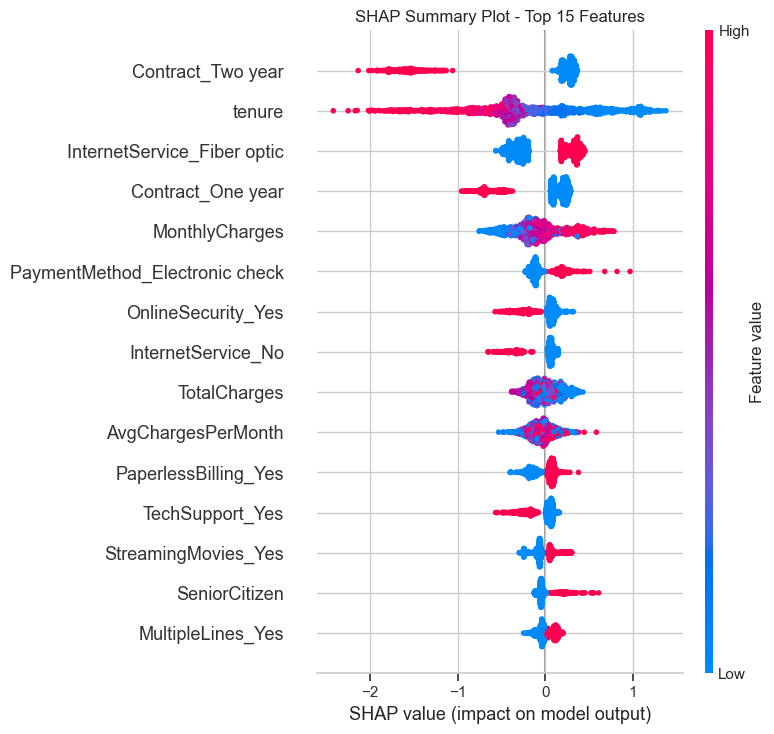

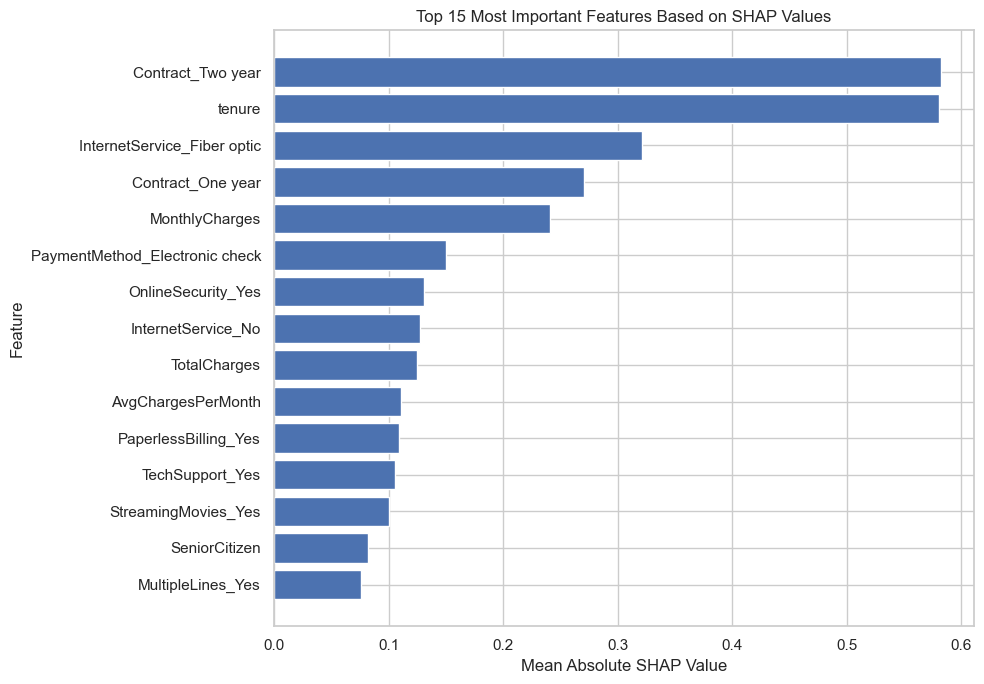

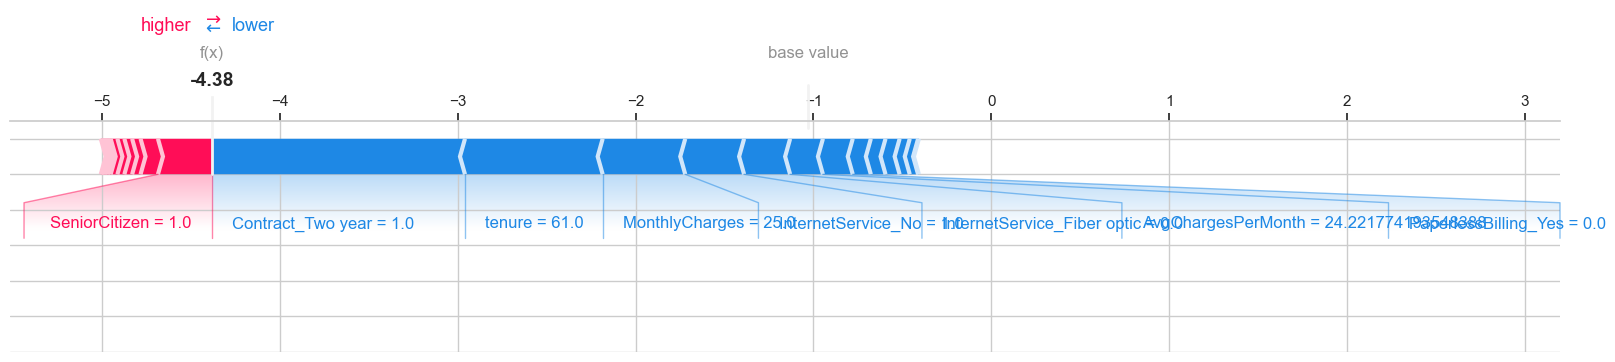

In [20]:
# ==========================================
# 13. SHAP INTERPRETABILITY
# ==========================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure X_test is still a DataFrame with column names
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Use the trained XGBoost model
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_df)

# -------------------------------
# A) SHAP Summary Plot (Top 15)
# -------------------------------
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_df,
    max_display=15,
    show=False
)
plt.title("SHAP Summary Plot - Top 15 Features")
plt.tight_layout()
plt.show()

# -------------------------------
# B) Mean Absolute SHAP Bar Plot
# -------------------------------
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_n = 15
top_idx = np.argsort(mean_abs_shap)[-top_n:]

plt.figure(figsize=(10, 7))
plt.barh(
    X_test_df.columns[top_idx],
    mean_abs_shap[top_idx]
)
plt.title("Top 15 Most Important Features Based on SHAP Values")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# -------------------------------
# C) Optional: Local explanation
# -------------------------------
sample_index = 0

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test_df.iloc[sample_index],
    matplotlib=True
)
plt.show()

### 14.Save Model

In [21]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/best_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

print("Model and scaler saved successfully ✅")
os.listdir("../models")# to check it is working or not


Model and scaler saved successfully ✅


['best_model.pkl', 'scaler.pkl']

### 15.Business Recommendation and Insights

### Key Drivers of Churn
- Month-to-month contracts
- High monthly charges
- Low tenure customers
- Fiber optic internet users

### Business Recommendations
- Incentivize long-term contracts
- Target customers in first 6 months
- Provide loyalty discounts for high-paying users
- Improve fiber customer experience
